0.99999


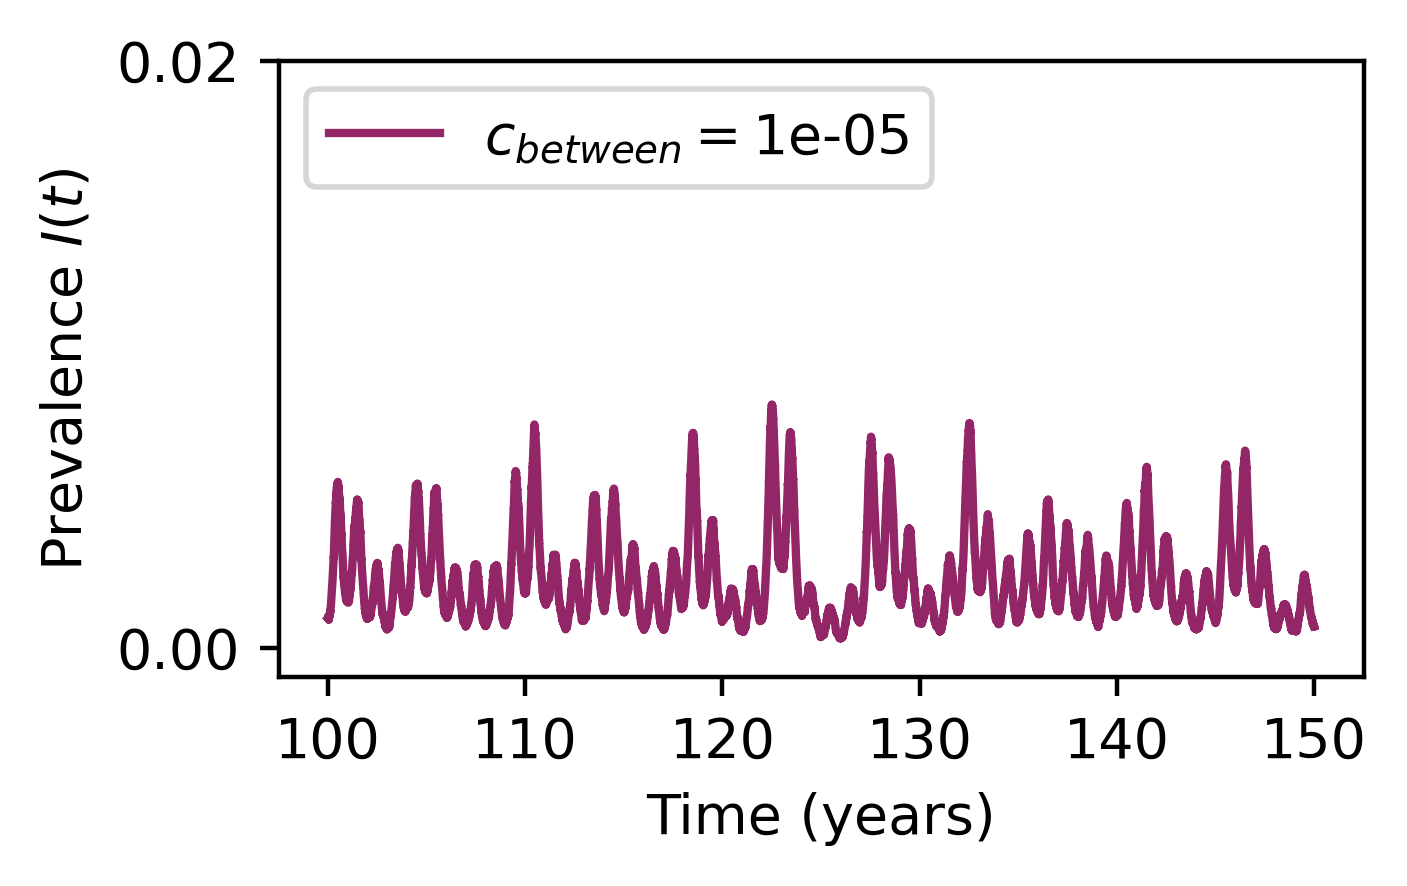

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fpath = "metapopulation/metagil_099999.csv"
#fpath = "metapopulation/metagil_0999.csv"
#fpath = "metapopulation/metagil_09.csv"


df = pd.read_csv(fpath)
c_within = fpath.split("/")[-1].split("_")[-1].split(".csv")[0]
c_within_float = float("." + c_within[1:])
print(c_within_float)

c_between = 1-c_within_float
c_between *= 1e6
c_between = np.round(c_between)
c_between /= 1e6 # For nicer formatting

# columns (I0, I1, ... )
S_cols = [c for c in df.columns if c.startswith("S")]
I_cols = [c for c in df.columns if c.startswith("I")]
R_cols = [c for c in df.columns if c.startswith("R")]


plt.figure(figsize=(3.5,2), dpi=400)

# total infected
I_total = df[I_cols].sum(axis=1).values

pop_total = df[S_cols].sum(axis=1).values + df[I_cols].sum(axis=1).values + df[R_cols].sum(axis=1).values

plot_mask = df["t"]/52 > 100
t_plot = df["t"][plot_mask]/52

plot_total = False

if plot_total:    
    I_plot = I_total[plot_mask]/pop_total[plot_mask]
    plt.plot(t_plot, I_plot, label=r'$I(t)$, ' + r"$N_0=$" + f'{pop_total[0]:,}', color=plt.cm.inferno(0.4))

for i, c in enumerate(I_cols[:1]):
    cS = S_cols[i]
    cI = I_cols[i]
    cR = R_cols[i]
    S = df[cS]
    I = df[cI]
    R = df[cR]
    pop_total_loc = S + I + R
    I_plot = I[plot_mask]/pop_total_loc[plot_mask]
    #plt.plot(t_plot, I_plot, alpha=1.0, color=plt.cm.inferno(0.4), label=r"$N_0=$" + f'{pop_total[0]:,}, ' + r"$N_i=$" + f'{pop_total_loc[0]:,}')
    plt.plot(t_plot, I_plot, alpha=1.0, color=plt.cm.inferno(0.4), label=r"$c_{between}=$" + f'{c_between:,}')



#plt.plot(t_vals, S_vals/N0, label='S', color='blue')
#plt.plot(np.array(t_vals)[-10000000:]/52, np.array(I_vals)[-10000000:]/N0, label='', color='red')

#plt.plot(t_vals, R_vals/N0, label='R', color='green')
plt.xlabel('Time (years)')
plt.ylabel(r'Prevalence $I(t)$')
#plt.title(f'Seasonal SIRS (Gillespie, ' + r"$N_0=$" + f'{N0:,})')
plt.legend(loc='upper left')
plt.grid(False)
plt.ylim([-0.001, 0.02])
plt.yticks([0, 0.02])
plt.show()

